# Logistic Regression From Scratch

In this section, Logistic Regression is implemented entirely from scratch using NumPy without relying on machine learning libraries such as scikit-learn.

The implementation includes:

- Gradient Descent optimization
- Binary Cross-Entropy Loss
- Sigmoid activation function
- L1 (Lasso) Regularization
- L2 (Ridge) Regularization
- Elastic Net Regularization
- Probability prediction (`predict_proba`)
- Decision function
- Configurable classification threshold
- Confusion Matrix
- Precision, Recall, and F1-score
- Training loss visualization

The implementation is designed to closely follow the behavior of scikit-learn's `LogisticRegression` while keeping the underlying optimization process transparent and easy to understand.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Iteration 100: Cost = 0.068656
ّFirst Cost: 0.693147
Final Cost: 0.068656
[0.09574208 0.96706712]
0.06865632184699164
[0 1]
{'feature_0': 1.1604600583903895, 'feature_1': -1.652166429105933}
100.0
[-2.24545673  3.37979625]
[[1 0]
 [0 1]]
1.0 1.0 1.0


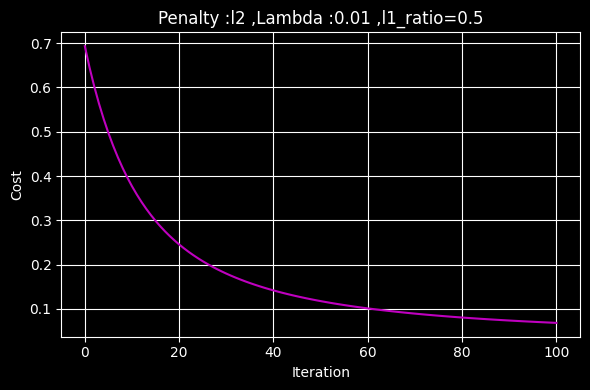

In [12]:

class LogisticRegression:
    def __init__(self , max_iter=100, learning_rate=0.1 , tol=1e-6 , lambda_ = 0.01 , penalty="l2",l1_ratio=0.5):
        if penalty == "elasticnet":
            if not (0 <= l1_ratio <= 1):
                raise ValueError("l1_ratio must be between 0 and 1.")

        self.l1_ratio = l1_ratio
        if lambda_ < 0:
            raise ValueError("lambda_ must be non-negative")
        self.lambda_ = lambda_
        penalty = penalty.lower()

        if penalty not in ("none", "l1", "l2","elasticnet"):
            raise ValueError("penalty must be one of: 'none', 'l1', 'l2', 'elasticnet'")

        self.penalty = penalty
        self.x = None
        self.w =None
        self.b = 0
        self.y = None
        if learning_rate <=0 :
            raise ValueError("Learning Rate must be more than zero.")
        self.learning_rate = learning_rate
        if tol < 0:
            raise ValueError("Tolerance must be more than zero.")
        self.tolerance = tol
        if max_iter <= 0:
            raise ValueError("max_iter must be more than zero.")
        self.max_iter = max_iter
        self.n=None
        self.cost_history = None
    def fit(self ,x_train, y_train ) :
        x_train = np.asarray(x_train)
        y_train = np.asarray(y_train)
        if x_train.ndim != 2:
            raise ValueError("Expected a 2D array.")
        if y_train.ndim != 1:
            raise ValueError("Expected a 1D array.")
        if len(x_train) != len(y_train):
            raise ValueError("length of y_train is not equall to length of x_train")
        self.x = x_train
        self.y = y_train
        self.cost_history=[]
        self.w = np.zeros(self.x.shape[1])
        self.n=self.x.shape[0]
        self.cost_history.append(self.compute_cost())
        previous_cost = self.cost_history[-1]
        for i in range(1,self.max_iter+1):
            self.compute_gradient()
            current_cost = self.compute_cost()
            self.cost_history.append(current_cost)
            if previous_cost is not None:
                if abs( current_cost- previous_cost) < self.tolerance:
                    break
            previous_cost = current_cost
            if i % 100 == 0:
                print(f"Iteration {i}: Cost = {self.cost_history[-1]:.6f}")
        print(f"ّFirst Cost: {self.cost_history[0]:.6f}\nFinal Cost: {self.cost_history[-1]:.6f}")
        return self
    def linear_model(self , x):
        return np.dot(x,self.w) + self.b
    def sigmoid(self,x):
        
        if x.shape[1] != len(self.w):
            raise ValueError("The number of input features does not match the trained model.")
        z = np.clip(self.linear_model(x), -500, 500)
        return 1 / (1 + np.exp(-z))
    def predict_proba(self,x):
        x = np.asarray(x)
        if x.ndim != 2:
            raise ValueError("The array must be two dimenstionals.")
        return self.sigmoid(x)
    def regularization_cost(self):
        if self.penalty == "l2":
            L2_penalty = (0.5*self.lambda_/self.n)*np.sum(np.power(self.w, 2))
            return L2_penalty
        elif self.penalty == "l1":
            L1_penalty = (self.lambda_/self.n)*np.sum(np.abs(self.w))
            return L1_penalty
        elif self.penalty == "elasticnet":
            elastic_penalty = (
            (self.lambda_ / self.n)
            * (
                self.l1_ratio * np.sum(np.abs(self.w))
                + (1 - self.l1_ratio) * 0.5 * np.sum(self.w ** 2)
            )
                )
            return elastic_penalty
        else :
            return 0
    def _regularization_gradient(self):
        if self.penalty == "l2":
            return  (self.lambda_/self.n)*self.w
        elif self.penalty == "l1":
            return  (self.lambda_/self.n)*np.sign(self.w)
        elif self.penalty == "elasticnet":
            regularization = (
            (self.lambda_ / self.n)
            * (
            self.l1_ratio * np.sign(self.w)
            + (1 - self.l1_ratio) * self.w
            ))

            return regularization
        else :
            return 0
    def compute_cost(self):
        y_pred = np.clip(self.predict_proba(self.x), 1e-15, 1 - 1e-15)
        j=(-1/self.n) * np.sum(self.y*np.log(y_pred) + (1-self.y)*np.log(1-y_pred))
        return j+self.regularization_cost()
    def compute_gradient(self):
        y_pred = self.predict_proba(self.x)
        error = y_pred - self.y 

        dw = (1/self.n) * self.x.T @ error
        db = (1/self.n) * np.sum( error )
        self.b = self.b - self.learning_rate*db
        
        self.w  = self.w - self.learning_rate*(dw + self._regularization_gradient())
        
        return 
    def predict(self , x_test , threshold=0.5):
        if not (0 <= threshold <= 1):
            raise ValueError("threshold must be between 0 and 1")
        if x_test.ndim != 2:
            raise ValueError("Expected a 2D array.")
        return (self.sigmoid(x_test) >= threshold).astype(int) 
    def get_weights(self):# -> dict:
        return {f"feature_{i}": weight.item() for i, weight in enumerate(self.w)}
    def score(self , x_test , y_test):
        return  ((len(y_test) - np.sum(np.abs(np.array(self.predict(x_test)) - np.array(y_test)))) / len(y_test))*100
    def decision_function(self, x):
        if x.ndim != 2:
            raise ValueError("Expected a 2D array.")

        if x.shape[1] != len(self.w):
            raise ValueError(
            "The number of input features does not match the trained model."
            )

        return self.linear_model(x)
    def confusion_matrix(self ,x_test ,y_test):
        y_test = np.asarray(y_test)

        if y_test.ndim != 1:
            raise ValueError("Expected a 1D array.")
        y_pred = self.predict(x_test)
        tp = np.sum((y_test == 1) & (y_pred == 1))
        tn = np.sum((y_test == 0) & (y_pred == 0))
        fp = np.sum((y_test == 0) & (y_pred == 1))
        fn = np.sum((y_test == 1) & (y_pred == 0))
        cm=np.array([
            [tn, fp],
            [fn, tp]
            ])
        
        return cm
    def precision(self , x_test , y_test):
        fp, tp=self.confusion_matrix(x_test , y_test)[:,1]
        if tp + fp == 0:
            return 0.0
        return tp / (tp + fp)
    def recall(self , x_test ,y_test):
        
        fn , tp = self.confusion_matrix(x_test ,y_test)[1,:]
        if tp + fn == 0:
            return 0.0
        return tp / (tp + fn)
    def f1_score(self , x_test , y_test):
        pre = self.precision(x_test , y_test)
        recall = self.recall(x_test , y_test)
        if pre + recall == 0:
            return 0.0
        return 2 * pre *recall / (pre + recall)
    def plot_loss(self):
        plt.figure(figsize=(6,4))
        plt.plot(np.arange(len(self.cost_history)),self.cost_history , color="m")
        plt.xlabel("Iteration")
        plt.ylabel("Cost")
        plt.grid(True)
        plt.title(f"Penalty :{self.penalty} ,Lambda :{self.lambda_} ,l1_ratio={self.l1_ratio}")
        plt.tight_layout()
        return plt.show()
d=LogisticRegression()
f=d.fit(np.array([[2, 3],
                          [4, 1]]) , np.array([0,1]))
print(d.predict_proba(np.array([[1, 2],
                                [3, 0]])))
print(d.compute_cost())
print(d.predict(np.array([[1, 2],
                          [3, 0]])))
print(d.get_weights())
print(d.score(np.array([[1, 2],
                          [3, 0]]) , [0,1]))
print(d.decision_function(np.array([[1, 2],
                          [3, 0]])))
print(d.confusion_matrix(np.array([[1, 2],
                                [3, 0]]) ,[0,1]))
print(d.precision(np.array([[1, 2],
                                [3, 0]]) ,[0,1]) , d.recall(np.array([[1, 2],
                                [3, 0]]) ,[0,1]) ,d.f1_score(np.array([[1, 2],
                                [3, 0]]) ,[0,1]))
d.plot_loss()

Iteration 100: Cost = 0.674225
Iteration 200: Cost = 0.656449
Iteration 300: Cost = 0.639741
Iteration 400: Cost = 0.624025
Iteration 500: Cost = 0.609228
Iteration 600: Cost = 0.595283
Iteration 700: Cost = 0.582125
Iteration 800: Cost = 0.569695
Iteration 900: Cost = 0.557939
Iteration 1000: Cost = 0.546806
Iteration 1100: Cost = 0.536249
Iteration 1200: Cost = 0.526227
Iteration 1300: Cost = 0.516700
Iteration 1400: Cost = 0.507635
Iteration 1500: Cost = 0.498997
Iteration 1600: Cost = 0.490758
Iteration 1700: Cost = 0.482890
Iteration 1800: Cost = 0.475369
Iteration 1900: Cost = 0.468173
Iteration 2000: Cost = 0.461280
Iteration 2100: Cost = 0.454671
Iteration 2200: Cost = 0.448329
Iteration 2300: Cost = 0.442238
Iteration 2400: Cost = 0.436382
Iteration 2500: Cost = 0.430749
Iteration 2600: Cost = 0.425324
Iteration 2700: Cost = 0.420097
Iteration 2800: Cost = 0.415057
Iteration 2900: Cost = 0.410192
Iteration 3000: Cost = 0.405495
Iteration 3100: Cost = 0.400956
Iteration 3200: C

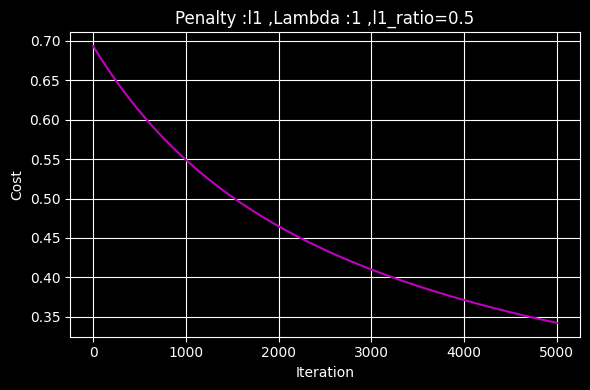

None


In [20]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Load Dataset
data = load_breast_cancer()

X = data.data
y = data.target

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
S=StandardScaler()
X_train = S.fit_transform(X_train)
X_test = S.transform(X_test)
# ------------------------------
# Without Regularization
# ------------------------------

model1 = LogisticRegression(
    learning_rate=0.0001,
    max_iter=5000,
    lambda_=0
)

model1.fit(X_train, y_train)

print("=" * 50)
print(f"Without {model1.penalty}")
print("=" * 50)

print("Accuracy :", model1.score(X_test, y_test))
print("Weights Norm :", np.linalg.norm(model1.w))
print("Weights :")
print(model1.w)

# ------------------------------
# With Regularization
# ------------------------------

model2 = LogisticRegression(
    learning_rate=0.0001,
    max_iter=5000,
    lambda_=1,
    penalty="l1",
    l1_ratio=0.5
)

model2.fit(X_train, y_train)

print("\n" + "=" * 50)
print(f"With {model2.penalty} , (lambda ={model2.lambda_} )")
print("=" * 50)

print("Accuracy :", model2.score(X_test, y_test))
print("Weights Norm :", np.linalg.norm(model2.w))
print("Weights :")
print(model2.w)
print(model2.plot_loss())

With l2 , (lambda =100 )
==================================================
Accuracy : 96.49122807017544
Weights Norm : 0.3806972907744156

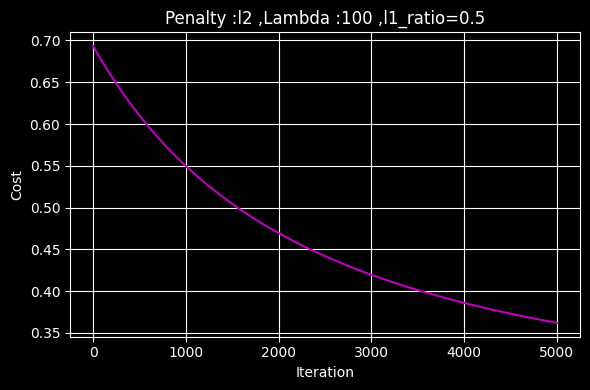

With l2 , (lambda =1 )
==================================================
Accuracy : 96.49122807017544
Weights Norm : 0.39941695580122044

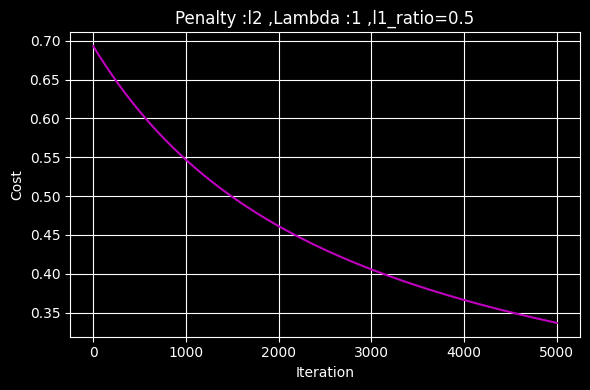

With l2 , (lambda =0.1 )
==================================================
Accuracy : 96.49122807017544
Weights Norm : 0.39959368950997876

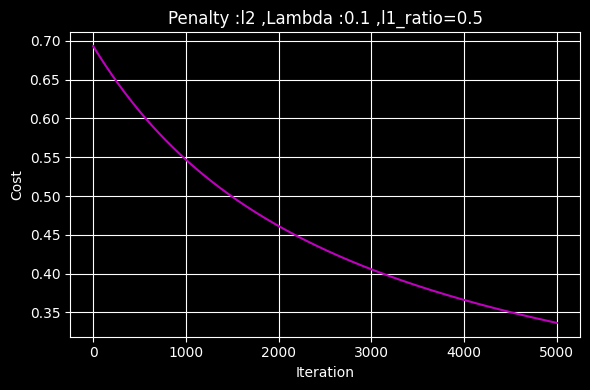

With l1 , (lambda =0.1 )
==================================================
Accuracy : 96.49122807017544
Weights Norm : 0.39926146052220185

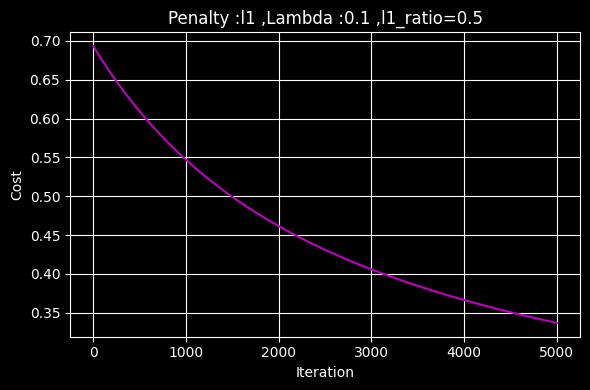

With l1 , (lambda =1 )
==================================================
Accuracy : 96.49122807017544
Weights Norm : 0.3961012307238735

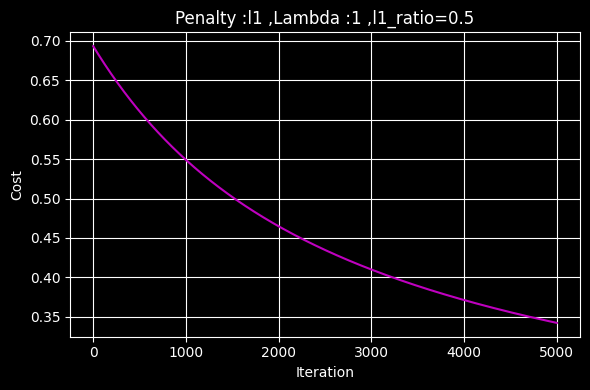

With l1 , (lambda =100 )
==================================================
Accuracy : 96.49122807017544
Weights Norm : 0.016403522645031227

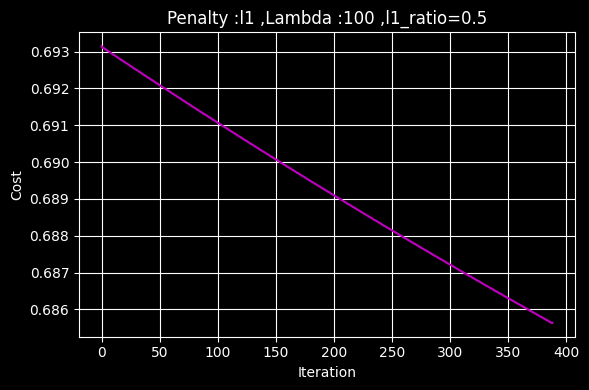


With elasticnet , (lambda =0.1 )
==================================================
Accuracy : 96.49122807017544
Weights Norm : 0.39949401363668235

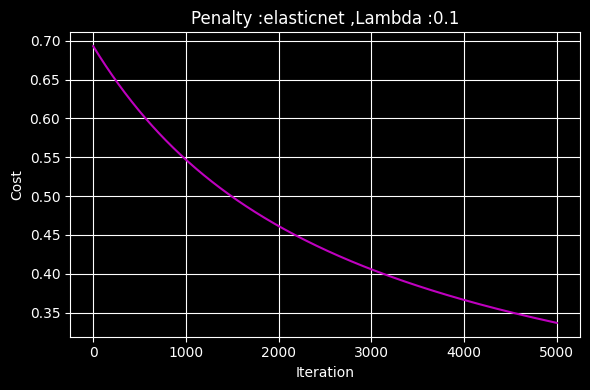

With elasticnet , (lambda =1 )
==================================================
Accuracy : 96.49122807017544
Weights Norm : 0.39842098457424313

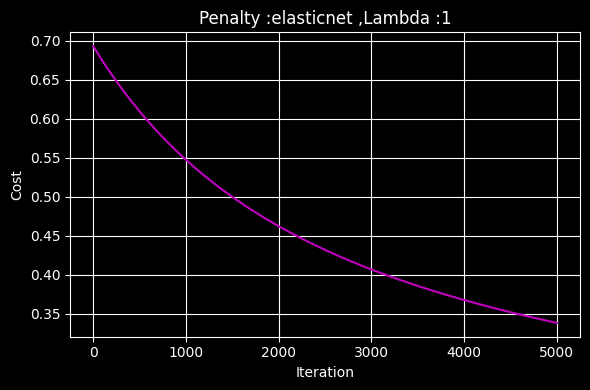

With elasticnet , (lambda =100 )
==================================================
Accuracy : 97.36842105263158
Weights Norm : 0.2936093827531501

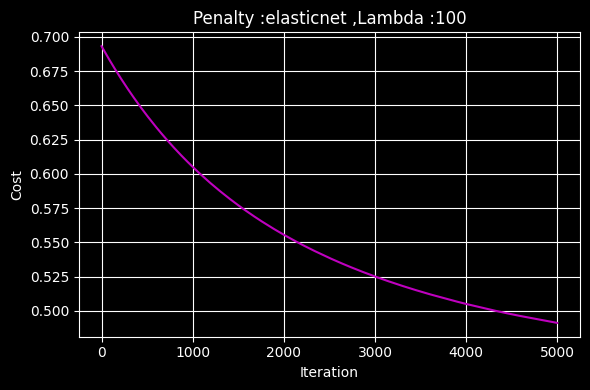

With elasticnet , (lambda =100 ) , l1_ratio=0.7
==================================================
Accuracy : 97.36842105263158
Weights Norm : 0.15524214273514703

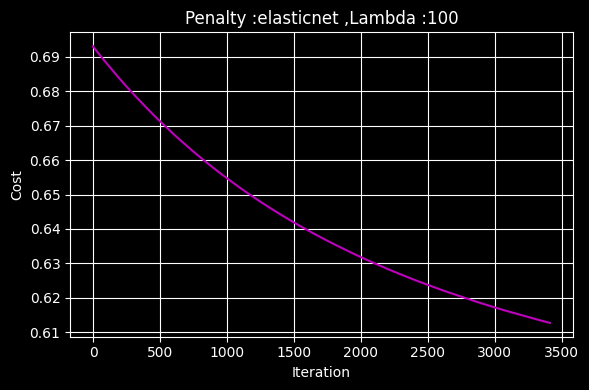

With elasticnet , (lambda =100 ) ,l1_ratio=0.9
==================================================
Accuracy : 96.49122807017544
Weights Norm : 0.06660864691161762

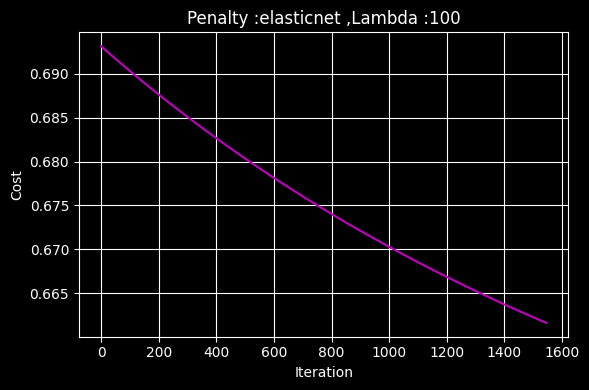

With elasticnet , (lambda =100 ) ,l1_ratio=0.6
==================================================
Accuracy : 97.36842105263158
Weights Norm : 0.21052778098075506

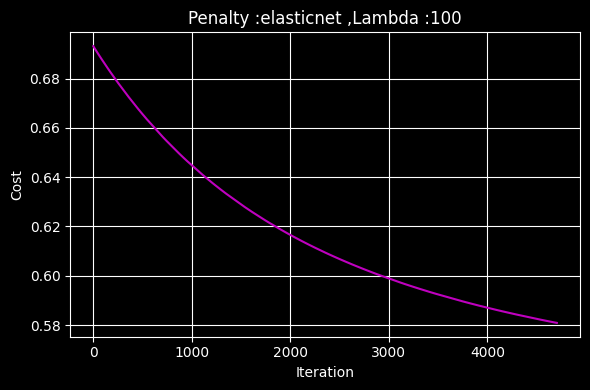

| Regularization | Lambda (λ) | L1 Ratio | Accuracy | Weight Norm | Interpretation |
|:--------------|-----------:|----------:|---------:|------------:|:---------------|
| L2 | 100 | — | 96.49% | 0.380697 | Strong coefficient shrinkage while preserving accuracy. |
| L2 | 1 | — | 96.49% | 0.399417 | Mild regularization effect. |
| L2 | 0.1 | — | 96.49% | 0.399594 | Almost identical to the unregularized model. |
| L1 | 100 | — | 96.49% | 0.016404 | Produces a very sparse model; most coefficients shrink close to zero. |
| L1 | 1 | — | 96.49% | 0.396101 | Moderate sparsity begins to appear. |
| L1 | 0.1 | — | 96.49% | 0.399261 | Very small coefficient reduction. |
| Elastic Net | 100 | 0.5 | **97.37%** | 0.293609 | Balanced L1/L2 regularization; improved generalization and accuracy. |
| Elastic Net | 100 | 0.6 | **97.37%** | 0.210528 | More sparsity while maintaining the best accuracy. |
| Elastic Net | 100 | 0.7 | **97.37%** | 0.155242 | Strong sparsity with no loss in predictive performance. |
| Elastic Net | 100 | 0.9 | 96.49% | 0.066609 | L1 dominates; excessive sparsity slightly reduces performance. |
| Elastic Net | 1 | 0.5 | 96.49% | 0.398421 | Mild regularization with balanced L1/L2 effect. |
| Elastic Net | 0.1 | 0.5 | 96.49% | 0.399494 | Nearly identical to the unregularized model. |

# Regularization Comparison and Analysis

The effect of **L2**, **L1**, and **Elastic Net** regularization was evaluated using different values of **λ (lambda)** and **l1_ratio**.

## Key Observations

- **L2 Regularization** consistently reduced the magnitude of the coefficients while preserving the original classification accuracy (96.49%). This indicates improved model simplicity without sacrificing predictive performance.

- **L1 Regularization** promoted sparsity by driving many coefficients toward zero. With a sufficiently large λ, the model became significantly simpler while maintaining similar accuracy.

- **Elastic Net** combined the advantages of both L1 and L2. Increasing **l1_ratio** gradually increased sparsity, while the L2 component prevented excessive feature elimination.

- The best overall result was achieved with **Elastic Net (λ = 100)**, where the model reached **97.37% accuracy** with a substantially reduced weight norm, demonstrating better generalization.

- Increasing **l1_ratio** from **0.5** to **0.7** further reduced the coefficient norm without affecting accuracy. However, at **l1_ratio = 0.9**, the model became overly sparse and accuracy dropped, indicating the onset of **underfitting**.

## Conclusion

The experiments show the expected behavior of the three regularization techniques:

- **L2** shrinks coefficients.
- **L1** performs feature selection by encouraging sparse weights.
- **Elastic Net** provides the best balance between coefficient shrinkage and feature selection.

Among all tested configurations, **Elastic Net with λ = 100 and l1_ratio between 0.6–0.7 produced the strongest overall performance**, achieving the best trade-off between model complexity and predictive accuracy.

These experiments demonstrate the expected behavior of each regularization technique and highlight the trade-off between model complexity and predictive performance. Overall, Elastic Net achieved the best balance by combining coefficient shrinkage (L2) with feature selection (L1).